# Image Generation with the Image API

So far we only sent text and images *into* a model and got text back. Models can also generate images for us.

In this quick lesson, we will use the [Images API](https://developers.openai.com/api/docs/api-reference/images) to generate an image for us. 

Instead of the ImagesAPI, the ResponsesAPI can be used as well, see [Image generation guide](https://developers.openai.com/api/docs/guides/image-generation).

## Setup

In [1]:
import base64
from pathlib import Path

from dotenv import load_dotenv
from IPython.display import Image, display
from openai import OpenAI

load_dotenv(override=True)
client = OpenAI()

## Defining the model

Here we use the dedicated image model `gpt-image-2`, not the text models from the earlier notebooks.

Model Information: 
- [All Models](https://developers.openai.com/api/docs/models/all)
- [GPT Image 2](https://developers.openai.com/api/docs/models/gpt-image-2)

In [3]:
IMAGE_MODEL = "gpt-image-2"

## A small helper to save and show images

The model returns the image as a base64 string. This helper decodes it, writes it to the `files/` folder, and shows it right in the notebook, so we don't repeat that code in every example.

In [4]:
def save_and_show(image_base64, filename):
    image_path = Path("files") / filename
    image_path.write_bytes(base64.b64decode(image_base64))
    display(Image(filename=str(image_path)))
    return image_path

# Defining the prompt

the ImageAPI doesn't have `instructions` and `input`, or `system` and `user` prompts, only a single `prompt` parameter

In [5]:
PROMPT = (
    "Generate a realistic appetizing food photo of the following recipe: "
    "Veggie Egg Scramble with Avocado Toast "
    "Use: eggs, chopped vegetable mix, bell peppers, leafy greens, avocado, bread roll or bun, shredded cheese, jarred sauce/spread "
    "How: Sauté the chopped vegetables and greens in oil, scramble in the eggs, and melt in shredded cheese. Serve on toasted bun/roll with sliced avocado and a little sauce/spread."
)

## Generating an image

This is the most direct way: one call, prompt in, image out.

- `size` sets the resolution. `"auto"` lets the model choose, or pick one of the sizes defined in [Size and quality options](https://developers.openai.com/api/docs/guides/image-generation#size-and-quality-options).
- `quality` trades quality for speed and cost: `"low"`, `"medium"`, or `"high"`.

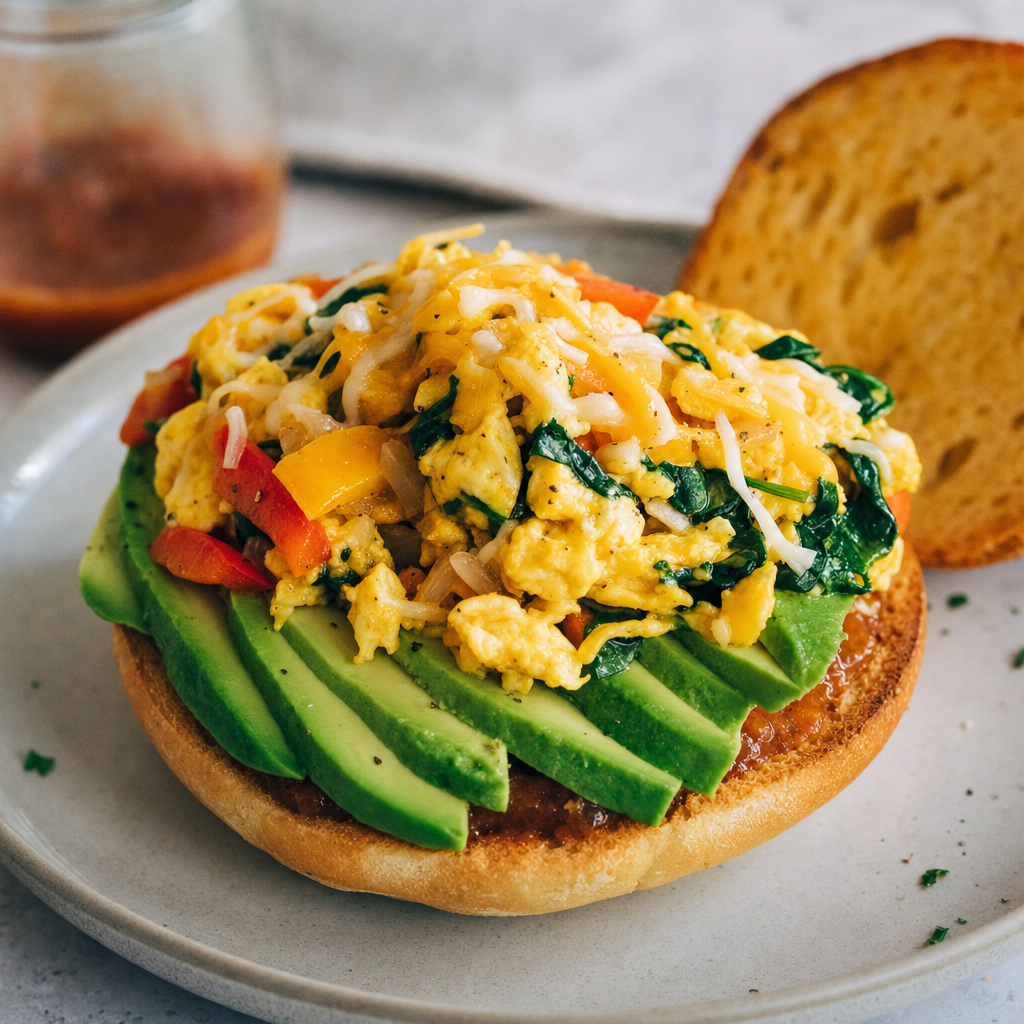

PosixPath('files/veggie-egg-scramble-toast-high.png')

In [8]:
response = client.images.generate(
    model=IMAGE_MODEL,
    prompt=PROMPT,
    size="1024x1024",
    quality="high",
)

save_and_show(response.data[0].b64_json, "veggie-egg-scramble-toast-high.png")

## Attention: Image Generation has high costs!

Image generation costs depend mostly on the model, image size, and quality, see [image generation cost calculator](https://developers.openai.com/api/docs/guides/image-generation#calculating-costs). The prompt text also costs a small number of input tokens, but for a short prompt it is usually much smaller than the image output cost.

Pricing can change, so check the [pricing page](https://developers.openai.com/api/docs/pricing) when exact costs matter.